# Variants of _K_-Means

In our previous chapter, we recalled the _K_-Means clustering algorithm, and learned its objective function. We also learned about the convergence of _K_-Means and how it is sensitive to the centroid initialization. It is popular and easy to implement, but as discussed in the previous chapter, there are flaws in the vanilla _K_-Means algorithm. To overcome those flaws, _K_-Means has other variants built on top of the original idea.

In this chapter, we will learn about some major flaws and the variants which address those flaws.


## Prerequisites

- _K_-Means

## Learning Objective
After reading this notebook, students should be able to:
- Interpret the limitations of KMeans and relate the variants to address them.





## _K_-Medoids Clustering

In the _K_-Means algorithm, we are calculating the mean of all data points in the cluster.
The calculation of mean considers all the points, even the outliers are considered.
If some point is an outlier and they are far away, then while computing means, they are forced into the cluster that distorts the shape of the cluster.
So, to bring robustness in the model and make the model resilient to outliers, _K_-Medoids can be used.


_K_-Medoids is a clustering algorithm similar to _K_-Means and have the same goal as of _K_-Means algorithm,
but they are more robust to noise and outliers. _K_-Medoids aims to minimize the absolute error criterion rather than SSE.

Unlike _K_-Means, _K_-Medoids uses real data points, called medoids instead of means, as the cluster centroids.
It avoids the effect of outliers on the resulting clusters.
A medoid is a point that has the minimal average distance to all other objects in the same cluster.
We can summarize the process of _K_-Medoids in few steps, as shown below:

### **_K_-Medoids algorithm**
**Steps:**
1. Select _K_ points as the initial medoids.
2. Assign each data point to the closest medoid $m$ and calculate cost.
3. Randomly select non-medoid data $x_i$.
4. Compute the total cost by swapping the medoid $m$ with non-medoid $x_i$.
5. If the cost is less than previous, then swap $m$ with $x_i$ to form the new set of _K_ medoids.
6. Repeat from step 2 - 5 until converge.


Let's look at a python code for the above algorithm and later in the programming material we will sum up the whole process.

```
k = <some_value>
threshold = <threshold_value>
data = <array of input feartures>
# function to randomly sample initial centroid
centers = initialize_centers(k)
from the dataset(medoids)
# sum of squared distance between
tot_cost = calculate_cost(centers, data)
centers and data points

cc, SWAPED = 0, True
while True:
    SWAPED = False

    for i in range(data.shape[0]):
        ## if that data is not a medoid
        if not i in centers:
            for j in range(len(centers)):

                ## make a copy of original centers for local use
                centers_ = np.copy(centers)
                centers_[j] = i

                ## local total cost
                tot_cost_ = calculate_cost(centers_, data)

                ## compare if differnece of local total
                ##cost and global total cost if less
                ##than the threshold  
                if tot_cost_ - tot_cost < threshold:

                    ## update total cost to local one
                    tot_cost = tot_cost_
                    
                    ## update centers
                    centers = centers_
                    SWAPED = True
    if cc > self.max_iter:
        break
    cc += 1
```






## _K_-Medians Clustering

_K_-Medians clustering is similar to the _K_-Means algorithm, but instead of calculating the means, they calculate the median for each cluster. The working process of _K_-Medians is similar to _K_-Means. This algorithm also chooses _K_ cluster centers that aim to minimize the sum of the distance between the data points and the closest cluster center. However, _K_-Medians uses the L1 norm, i.e., absolute distance as the distance metric as opposed to the squared distance metric used in _K_-Means.
$$
\sum^K_{k=1} \sum_{x_i \in C_k} |x_{ij} - \text{median}_{kj}|
$$

where,

$x_{i j}$ represents the $j^{th}$ attribute of the instance $x_i \in X$,

$\text{median}_{k j}$ represents the median for the $j^{th}$
attribute in the $k^{th}$ cluster $C_k$

Like _K_-Medoids, this variant is also used when there is presence of outliers in the dataset. Since median values are not as sensitive as mean to the outliers, _K_-Median can be used instead of _K_-Means to lower the effects of outliers.

Let's look at a small code snippet below for the implementation of _K_-Median.

```
n_centers = <number of centers(k)>
data = <array of input feartures>
centers = <array of centroids>
cluster_label = <array of assigned cluster labels>

for i in range(n_centers):
        ## update centroids with the median among the row    
        centers[i] = np.median(data[cluster_label == i], axis=0)
        
```

## _K_-Modes Clustering

_K_-Modes is another variant of _K_-Means, which calculates modes instead of means. One flaw in _K_-Means is it cannot deal with categorical features. Using certain transformations categorical features can be converted to the numerical and _K_-Means can be applied, but this method does not produce good clusters due to the fact that SSE and mean are not appropriate for categorical data. Hence, the _K_-Modes algorithm is used to deal with such categorical features. It takes the mode(most frequent) value from the cluster as a centroid.

_K_-Modes uses simple matching dissimilarity between two objects as a distance metric. Smaller the distance, more similar two objects are. Let's look at the distance function:
Here, let $A$ and $B$ be two categorical objects. Now the distance between these two object is measured by:
$$
d(A, B) = \sum^N_{i=1} \delta_i
$$

where, $N$ is total number os samples and
where $N$ is the total number of features and

$\delta_i = \delta(a_i, b_i) = \begin{cases}
    0 & \text{if } a_i = b_i \\
    1 & \text{if } a_i \neq b_i
\end{cases}$

### **_K_-Modes Algorithm**

1. Pick random _K_ samples as an initial centroid
2. Assign the data to its nearest centroid
3. Calculate the mode to update the centroid
4. Repeat step 2 and 3 until no change in centroid


## _K_-Prototype Clustering

As discussed above, _K_-Modes can be used for categorical features, but what if we have mixed features?

We have to use a different method to deal with such features, and here _K_-prototype come into play.

In simple words, _K_-prototype is the combination of _K_-Means to deal with continuous numerical features and _K_-Modes for categorical features.

$$
K\mbox{-prototype} = K\mbox{-means for numeric} + K\mbox{-modes for categorical features}
$$

For the distance metric, _K_-prototype uses Hamming Distance for categorical and like _K_-Means- euclidean for numerical.

We will not discuss about hamming distance here in detail but in a simple term, hamming distance outputs the number of positions at which the corresponsing data of given string of two equal length is different. For example: Hamming distance of "Km**ode**" and "Km**ean**" is 3.

Let's look at the algorithm below:

### **_K_-Prototype Algorithm**

**Steps:**

1. Select _K_ initial centroids from the dataset $X$. It must be one for each cluster.

2. Allocate each points in $X$ to a cluster whose centroid is the nearest to it and update the centroid(using mean if numerical, mode if categorical).

3. After all points have been allocated to a cluster, retest the similarity of points against the current centroid. If you find that an point is found such that its nearest to another cluster centroid, update the centroid of both the clusters.

4. Repeat 3 until no object changes its cluster after fully testing $X$.

*You can refer to additional material for more details on the whole process of _K_-Prototype.*

## Mini Batch _K_-Means




Mini batch _K_-Means uses the mini-batches to reduce the computation time, while still attempting to optimize the same objective function as _K_-Means. In _K_Means, we consider all the data points at the same time. It is fine for small datasets, but when we have large datasets, then calculating distances of the whole batch can be computation heavy. Mini-batch _K_-Means attemptes to solve this problem by creating chunks of big dataset to mini-batches and perform _K_-Means of those small chunks in each iteration. Each batch of data point is assigned to the cluster depending on previous centroid. It then updates the centroids based on the new batch.

Maximum iteration steps has to be set before running mini-batch _K_-Means else the algorithm will run forever.

Let's look at the steps and later we will implement the algorithm using `sklearn`.

### **Mini-Batch _K_-Means Algorithm**

1. Initialize value for `n` number of batches and `t` iteration step.
2. Chunk dataset into `n` mini batches.
3. Apply K-Means on those batches and update centroids.
4. Run until iteration steps.


Let's look at the implementation using `sklearn` below:



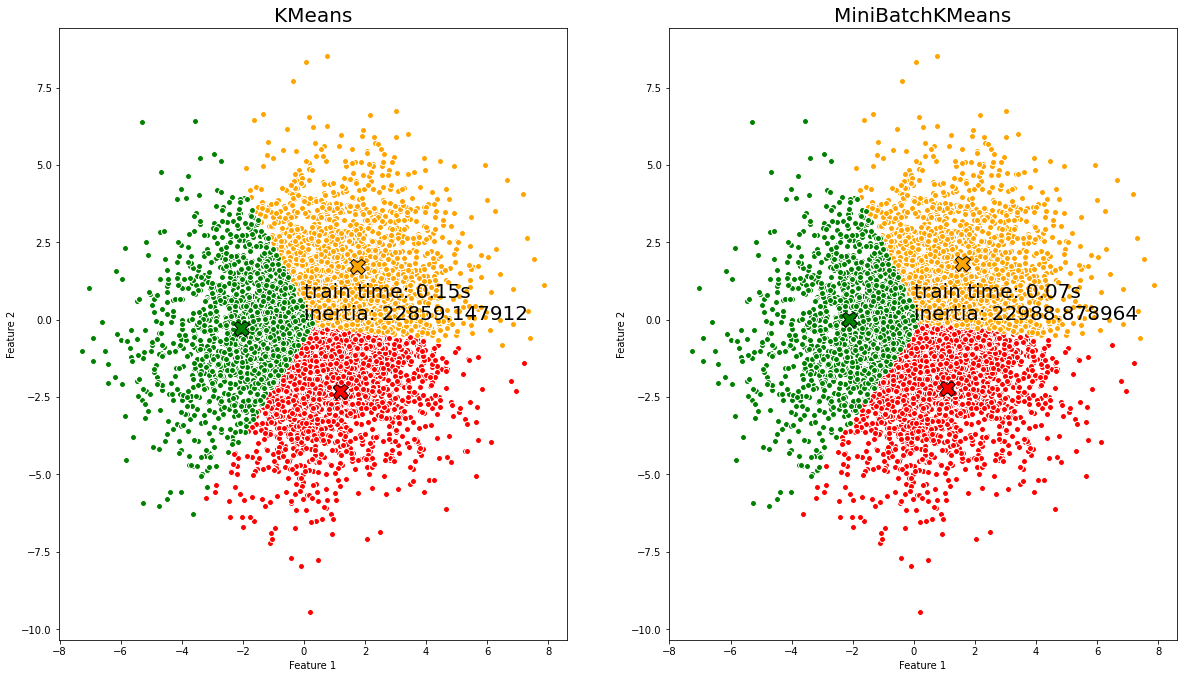

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.datasets import make_blobs

## Generate sample data
np.random.seed(99)

batch_size = 45 # batch size for mini batches
centers = [[1, 1], [-1, -1], [1, -1]]
n_clusters = len(centers)
X, labels_true = make_blobs(n_samples=5000, centers=centers, cluster_std=2)

## Compute clustering with Means

k_means = KMeans(init='k-means++', n_clusters=3)
t0 = time.time()
k_means.fit(X)
t_batch = time.time() - t0

## Compute clustering with MiniBatchKMeans

mbk = MiniBatchKMeans(init='k-means++', n_clusters=3, batch_size=batch_size)
t0 = time.time()
mbk.fit(X)
t_mini_batch = time.time() - t0

## Plot result

fig = plt.figure(figsize=(25, 10))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)

colors = ['red', 'orange', 'green']

## We want to have the same colors for the same cluster from the
## MiniBatchKMeans and the KMeans algorithm. Let's pair the cluster centers per
## closest one.
k_means_cluster_centers = k_means.cluster_centers_
order = pairwise_distances_argmin(k_means.cluster_centers_,
                                  mbk.cluster_centers_)

mbk_means_cluster_centers = mbk.cluster_centers_[order]

k_means_labels = pairwise_distances_argmin(X, k_means_cluster_centers)
mbk_means_labels = pairwise_distances_argmin(X, mbk_means_cluster_centers)

## KMeans
ax = fig.add_subplot(1, 3, 1)
for k, col in zip(range(n_clusters), colors):
    my_members = k_means_labels == k
    cluster_center = k_means_cluster_centers[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w',
            markerfacecolor=col, marker='o')
    ax.plot(cluster_center[0], cluster_center[1], 'X', markerfacecolor=col,
            markeredgecolor='k', markersize=15)
ax.set_title('KMeans', fontdict={'fontsize': '20'})
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')


plt.text(0, 0,  'train time: %.2fs\ninertia: %f' % (
    t_batch, k_means.inertia_), fontdict={'fontsize': '20'}, )

## MiniBatchKMeans
ax = fig.add_subplot(1, 3, 2)
for k, col in zip(range(n_clusters), colors):
    my_members = mbk_means_labels == k
    cluster_center = mbk_means_cluster_centers[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w',
            markerfacecolor=col, marker='o')
    ax.plot(cluster_center[0], cluster_center[1], 'X', markerfacecolor=col,
            markeredgecolor='k', markersize=15)
ax.set_title('MiniBatchKMeans', fontdict={'fontsize': '20'})
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

plt.text(0, 0, 'train time: %.2fs\ninertia: %f' %
         (t_mini_batch, mbk.inertia_), fontdict={'fontsize': '20'}, )


plt.show()

As you can see in the plot above, mini-batch _K_-Means took less train time than the _K_-Means algorithm to train on the `5000` data samples.

## Bisecting _K_-Means



Bisecting _K_-Means algorithm is an extension of the original vanilla _K_-Means algorithm, where the number of clusters is added incrementally. In Bisecting _K_-Means, the original _K_-Means is applied, and the cluster is split repeatedly until the number of required clusters is reached. Following is the Bisecting _K_-Means Algorithm.

### **Bisecting _K_-Means Algorithm**

**Steps:**

1. Set _K_-required

2. Set _K_ = 1

3. Find the centroid of the dataset for _K_=1 cluster.

4. If _K_ < _K_-required:
    * Split a cluster with maximum SSE by using _K_-Means
    * _K_ = _K_+1

5. Repeat step 4 until _K_=_K_-required.

<div align="center">
    <figure>
     <!-- <img style="max-height: 400px;" src="https://doc.google.com/a/fusemachines.com/uc?export=download&id=154gXESJIHyzxP79USuICK78-8PsCnJCn" > -->
     <img style= "max-height: 400px;" src="https://i.postimg.cc/pdR5s9HM/image.png">
     <figcaption>Figure 2: Bisecting <i>K</i>-Means</figcaption>.
    </figure>
</div>

Bisecting _K_-Means only requires splitting the cluster into two sub-clusters. This saves the computation cost of the algorithm. This algorithm also avoids the optimal local problem of _K_-Means clustering.


## Key Takeaways

- _K_-Medoids and _K_-Medians are more resilient to outliers than _K_-Means.

- A medoid is a point that has the minimal average distance to all other objects in the same cluster.

- The _K_-Modes algorithm is used to deal with categorical features.

- Mini batch _K_-Means and bisecting _K_-Means saves the computation cost.